In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import seaborn as sns
from itertools import cycle
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords  # Import stopwords
from nltk.stem import PorterStemmer
import nltk

In [2]:
#df = pd.read_csv(r'C:\Users\kiran\Downloads\Yelp JSON\reviews_20k.csv')
df = pd.read_csv(r'reviews_20k.csv')

In [3]:
df.head(5)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [4]:
df.shape

(20000, 9)

In [5]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
# Clean the text, convert to lowercase, remove non-alphabet characters, tokenize, apply stemming, and remove stopwords
def preprocess_text(text):
    text = text.lower().strip() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabet characters
    tokens = word_tokenize(text)  # Tokenize text into words
    stop_words = set(stopwords.words('english'))  # Set of English stopwords
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    stemmer = PorterStemmer()  # Initialize the Porter Stemmer
    tokens = [stemmer.stem(word) for word in tokens]  # Apply stemming
    return ' '.join(tokens)  # Join tokens back into a string

In [7]:
df['processed_text'] = df['text'].apply(preprocess_text)  # Applying preprocessing to the reviews

In [8]:
# We label 'Negative' for <= 2 stars, 'Positive' for 4 or 5 stars, 'Neutral' for 3 stars
def encode_labels(stars):
    if stars <= 2:
        return 'Negative'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Positive'

In [9]:
# New Column in dataset to Store lablel's
df['label'] = df['stars'].apply(encode_labels)

In [10]:
x = df['processed_text']
y = df['label']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
# Shape of train data set
print('x_train shape : ', x_train.shape)
print('y_train shape : ', y_train.shape)

x_train shape :  (16000,)
y_train shape :  (16000,)


In [12]:
# Shape of test data set
print('x_test shape : ', x_test.shape)
print('y_test shape : ', y_test.shape)

x_test shape :  (4000,)
y_test shape :  (4000,)


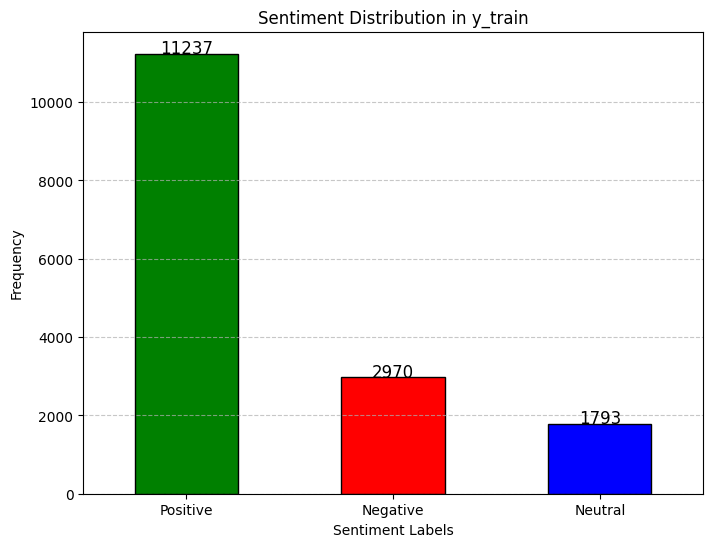

In [13]:
def bar_plot(data):
    class_counts = pd.Series(data).value_counts()

    # Plot bar chart
    class_counts.plot(kind="bar", color=["green", "red", "blue"], edgecolor="black", figsize=(8, 6))

    # Add values on top of each bar
    for i, v in enumerate(class_counts):
        plt.text(i, v + 0.2, str(v), ha="center", fontsize=12)

    # Customize plot
    plt.xlabel("Sentiment Labels")
    plt.ylabel("Frequency")
    plt.title("Sentiment Distribution in y_train")
    plt.xticks(rotation=0)  # Keep labels readable
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show the plot
    plt.show()

# Example usage
bar_plot(y_train)


In [14]:
# Import RandomUnderSampler
from imblearn.under_sampling import RandomUnderSampler

# Initialize RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

# Perform undersampling using the RandomUnderSampler
# Reshape X_train to 2D (required for RandomUnderSampler)
x_train_reshaped = x_train.values.reshape(-1, 1)

In [15]:
!pip install imbalanced-learn

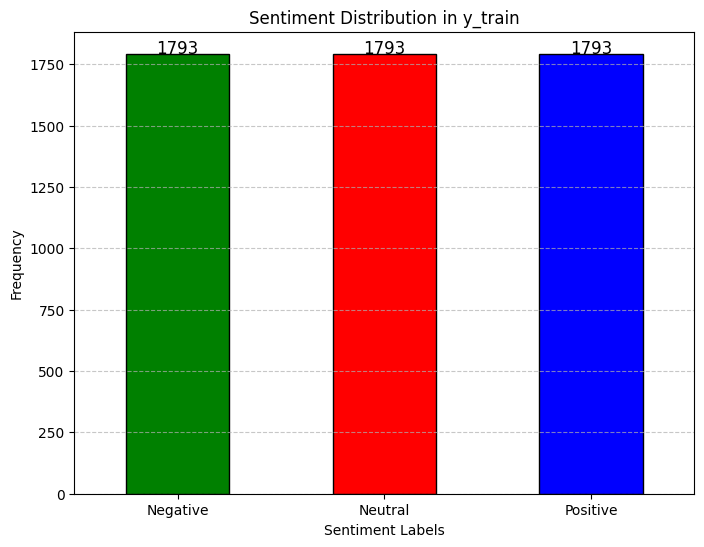

In [16]:
from imblearn.under_sampling import RandomUnderSampler

# Ensure x_train is reshaped to 2D (if it's a Series or 1D array)
x_train_reshaped = x_train.to_frame() if isinstance(x_train, pd.Series) else x_train.values.reshape(-1, 1)

# Initialize RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

# Perform undersampling
X_resampled, y_resampled = rus.fit_resample(x_train_reshaped, y_train)

# Now call the bar_plot function with y_resampled
bar_plot(y_resampled)
